In [1]:
!pip install spikingjelly torch torchvision plotly scikit-learn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 32.2 MB/s eta 0:00:00


In [2]:
!apt-get install -y git-lfs -q && git lfs install
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git
DATA_ROOT = './PlantVillage-Dataset/raw/color'

Reading package lists...
Building dependency tree...
Reading state information...
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Git LFS initialized.
Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 15.76 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [3]:
import os, gc, copy, json, math, time, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

In [4]:
try:
    from spikingjelly.activation_based import functional, surrogate
    from spikingjelly.activation_based import neuron as sj_neuron
    from spikingjelly.activation_based.base import MemoryModule
    SJ_AVAILABLE = True
    print("✅  SpikingJelly loaded")
except ImportError:
    SJ_AVAILABLE = False
    print("❌  SpikingJelly not found — run:  !pip install spikingjelly -q")
    raise SystemExit

warnings.filterwarnings("ignore")

✅  SpikingJelly loaded


In [5]:
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Hyperparameters

In [6]:
IMG_SIZE        = 128
BATCH_SIZE      = 32
NUM_WORKERS     = 2
T               = 8          # SNN timesteps per forward pass
CNN_DIM         = 512        # CNN backbone output width
ENC_DIM         = 256        # spike encoder / SNN width
EPOCHS          = 25         # increase to 40+ for production
LR              = 3e-4
WEIGHT_DECAY    = 1e-4
PATIENCE        = 8
SUBSET_FRAC     = 0.35       # 1.0 for full dataset
DATA_ROOT       = "./PlantVillage-Dataset/raw/color"

In [7]:
print(f"\n{'─'*55}")
print(f"  Device  : {DEVICE}")
if DEVICE.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"  GPU     : {p.name}  ({p.total_memory/1e9:.1f} GB)")
print(f"  T steps : {T}   ENC_DIM : {ENC_DIM}   Epochs : {EPOCHS}")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
  Device  : cuda
  GPU     : Tesla T4  (15.6 GB)
  T steps : 8   ENC_DIM : 256   Epochs : 25
───────────────────────────────────────────────────────


Izhikevich neuron definition

In [8]:
class IzhikevichNode(MemoryModule):
    """
    Izhikevich (2003) two-variable spiking neuron — SpikingJelly compatible.

    Model equations (Euler integration, dt = 0.5 ms for stability):
      dv/dt = 0.04v² + 5v + 140 − u + I
      du/dt = a(bv − u)
      if v ≥ v_th:  v ← c,  u ← u + d   (spike + reset)

    The four parameters {a, b, c, d} determine firing behaviour completely.
    All five canonical types are instances of this single class with
    different parameter values.

    Surrogate gradient:
      Forward  : spike = H(v − v_th)         (Heaviside, non-differentiable)
      Backward : dspike/dv ≈ ATan surrogate  (smooth, differentiable proxy)
    """

    def __init__(
        self,
        a: float,
        b: float,
        c: float,          # after-spike reset voltage  (mV)
        d: float,          # after-spike recovery jump
        v_threshold: float = 30.0,
        dt: float          = 0.5,
        surrogate_fn       = None,
        detach_reset: bool = True,
    ):
        super().__init__()
        self.a           = a
        self.b           = b
        self.c_val       = float(c)   # c is a Python keyword — rename
        self.d           = d
        self.v_threshold = v_threshold
        self.dt          = dt
        self.detach_reset = detach_reset
        self.surrogate_fn = surrogate_fn or surrogate.ATan()

        # register_memory: SpikingJelly resets these to init values on
        # functional.reset_net(model) — no manual state tracking needed
        self.register_memory("v", self.c_val)   # membrane potential (mV)
        self.register_memory("u", b * c)        # recovery variable

    # ── charge: Izhikevich sub-threshold dynamics ─────────────────────────
    def neuronal_charge(self, x: torch.Tensor):
        """
        Update v and u via Euler integration.
        x is the injected current I (output of the preceding Linear layer).
        """
        v = self.v
        u = self.u

        # Scalar → tensor broadcast on first call after reset
        if isinstance(v, float):
            v = torch.full_like(x, v)
        if isinstance(u, float):
            u = torch.full_like(x, u)

        dv = (0.04 * v * v + 5.0 * v + 140.0 - u + x) * self.dt
        du = self.a * (self.b * v - u) * self.dt

        self.v = (v + dv).clamp(-100.0, 35.0)
        self.u = (u + du).clamp(-100.0, 100.0)

    # ── fire: threshold crossing with surrogate gradient ──────────────────
    def neuronal_fire(self) -> torch.Tensor:
        return self.surrogate_fn(self.v - self.v_threshold)

    # ── reset: v←c and u←u+d at spike sites ──────────────────────────────
    def neuronal_reset(self, spike: torch.Tensor):
        sd = spike.detach() if self.detach_reset else spike
        self.v = (1.0 - sd) * self.v + sd * self.c_val
        if isinstance(self.u, float):
            self.u = torch.zeros_like(spike)
        self.u = self.u + sd * self.d

    # ── forward: charge → fire → reset (standard SpikingJelly flow) ───────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        self.neuronal_charge(x)
        spike = self.neuronal_fire()
        self.neuronal_reset(spike)
        return spike

Neuron type Config

In [9]:
NEURON_CONFIGS = {
    # ── a  controls recovery speed (large a = fast recovery)
    # ── b  controls sub-threshold sensitivity (larger b = stronger coupling)
    # ── c  is the after-spike reset voltage (more depolarised = faster re-fire)
    # ── d  is the after-spike recovery jump (large d = strong adaptation)

    "RS": dict(   # Regular Spiking
        a=0.02, b=0.20, c=-65.0, d=8.0,
        color="#3B82F6",
        display="Regular Spiking (RS)",
        bio="Tonic firing with adaptation · L2/3 & L5 excitatory pyramidal",
    ),
    "FS": dict(   # Fast Spiking
        a=0.10, b=0.20, c=-65.0, d=2.0,
        color="#EF4444",
        display="Fast Spiking (FS)",
        bio="High-frequency · no adaptation · PV+ inhibitory interneurons",
    ),
    "CH": dict(   # Chattering
        a=0.02, b=0.20, c=-50.0, d=2.0,
        color="#10B981",
        display="Chattering (CH)",
        bio="Burst trains · gamma sync · V1/V2 visual cortex L2/3",
    ),
    "IB": dict(   # Intrinsic Bursting
        a=0.02, b=0.20, c=-55.0, d=4.0,
        color="#F59E0B",
        display="Intrinsic Bursting (IB)",
        bio="Initial burst then tonic · L5 thick-tufted pyramidal",
    ),
    "LTS": dict(  # Low Threshold Spiking
        a=0.02, b=0.25, c=-65.0, d=2.0,
        color="#8B5CF6",
        display="Low Threshold Spiking (LTS)",
        bio="Low activation threshold · rebound burst · SST+ Martinotti",
    ),
}

Neuroscience Deep - dive

In [10]:
NEURON_BRAIN_INFO = {
    "RS": dict(
        region="Neocortical Layers II/III & V — Excitatory pyramidal neurons "
               "(Primary Visual Cortex V1, Prefrontal Cortex, Association Areas)",
        mechanism=(
            "RS neurons fire tonically with spike-frequency adaptation: high "
            "initial rate that slows as K+ afterhyperpolarisation builds up. "
            "Parameter d=8 produces the largest post-spike recovery jump of "
            "all five types, giving clear adaptation. They comprise ~70–80% "
            "of all cortical neurons and are the principal substrate of "
            "sustained sensory representation."
        ),
        image_verdict=(
            "GOOD. Adaptation acts as a temporal high-pass filter — suppresses "
            "uniform background texture, preserves responses at disease boundaries. "
            "Analogous to V1 simple cells encoding oriented edges and gratings. "
            "Stable gradient flow throughout training due to the regular, "
            "predictable spike pattern. Predicted rank: 2nd."
        ),
    ),
    "FS": dict(
        region="All cortical layers — GABAergic Parvalbumin+ (PV+) Basket & "
               "Chandelier interneurons (densest in L4 of primary sensory cortices)",
        mechanism=(
            "FS neurons fire at 200–800 Hz with NO adaptation: a=0.10 gives "
            "the fastest recovery constant of all five types. They provide "
            "feedforward inhibition and lateral sharpening that generates "
            "gamma oscillations (30–80 Hz). They receive the strongest "
            "thalamocortical drive and control the gain of cortical columns."
        ),
        image_verdict=(
            "BELOW AVERAGE for 38-class multi-label task. No adaptation means "
            "every timestep fires at maximum rate regardless of input structure, "
            "compressing the dynamic range of the mean-rate readout. The "
            "readout layer sees nearly identical activity vectors across "
            "dissimilar disease classes, reducing discriminability. "
            "Predicted rank: 4th."
        ),
    ),
    "CH": dict(
        region="Visual Cortex Layers II/III — Chattering cells in cat & primate "
               "V1/V2  (first described: Gray & McCormick, Science 1996)",
        mechanism=(
            "CH is the ONLY Izhikevich type discovered specifically in the "
            "visual cortex. c=−50 mV (most depolarised reset of all five) "
            "enables rapid burst re-initiation. Each burst (300–700 Hz) is "
            "followed by quiescence, creating a burst-silence rhythm that "
            "drives gamma-band synchrony for figure-ground segregation and "
            "perceptual binding — the exact computations needed for isolating "
            "disease lesions on leaf surfaces."
        ),
        image_verdict=(
            "OPTIMAL. ⭐ The burst-silence rhythm is a built-in attention "
            "gate: bursts fire for high-salience regions (disease spots, "
            "lesion boundaries, colour transitions), silence for uniform "
            "healthy background. Each burst encodes a compact multi-scale "
            "feature packet (texture statistics + contour curvature + colour "
            "gradient) within T timesteps. Direct biological homolog of the "
            "visual mechanism performing the identical spatial segmentation "
            "task in primate V1/V2. Predicted rank: 1st."
        ),
    ),
    "IB": dict(
        region="Neocortical Layer V — Thick-tufted pyramidal neurons "
               "(Primary Motor Cortex, Somatosensory Cortex, Visual Cortex L5b). "
               "Project to thalamus, brainstem, spinal cord.",
        mechanism=(
            "IB neurons fire an initial 2–5 spike burst ('salience alarm') "
            "followed by repetitive single spikes. c=−55 mV gives an "
            "intermediate reset voltage between RS (−65) and CH (−50). "
            "Large apical dendrites integrate broad spatial regions; "
            "the burst onset reliably signals the appearance of a new "
            "visual stimulus."
        ),
        image_verdict=(
            "STRONG. Excellent salience detection: the burst onset fires "
            "strongly when a distinctive feature (disease spot, necrotic "
            "patch) appears in the CNN feature map. Slightly weaker than CH "
            "for diffuse symptoms like early-stage yellowing where the "
            "burst advantage diminishes. Competes closely with RS overall. "
            "Predicted rank: 3rd."
        ),
    ),
    "LTS": dict(
        region="Cortical Layers I–IV — Somatostatin+ (SST+) Martinotti "
               "inhibitory interneurons (dense in supragranular visual cortex)",
        mechanism=(
            "LTS neurons have b=0.25 (highest sub-threshold coupling), "
            "giving a low activation threshold and post-inhibitory rebound "
            "bursting: after hyperpolarisation they fire a burst on rebound "
            "via the low-threshold Ca²⁺ spike. They target apical dendrites "
            "of pyramidal cells, providing layer-selective inhibition that "
            "shapes dendritic computation."
        ),
        image_verdict=(
            "BELOW AVERAGE for 38-class classification. The low threshold "
            "causes spurious responses to weak or noisy CNN features, "
            "increasing false-positive rate. The rebound burst mechanism "
            "is tuned to respond to inhibitory pauses, not sustained "
            "feature drive — mismatched to the CNN→SNN current injection "
            "mode used here. Predicted rank: 5th."
        ),
    ),
}


In [11]:
print("\nNeuron Type Configurations")
print(f"{'─'*62}")
print(f"  {'Type':<6}  {'a':>5}  {'b':>5}  {'c':>6}  {'d':>4}  Description")
print(f"{'─'*62}")
for k, v in NEURON_CONFIGS.items():
    print(f"  {k:<6}  {v['a']:>5.2f}  {v['b']:>5.2f}  "
          f"{v['c']:>6.1f}  {v['d']:>4.1f}  {v['bio']}")
print(f"{'─'*62}")


Neuron Type Configurations
──────────────────────────────────────────────────────────────
  Type        a      b       c     d  Description
──────────────────────────────────────────────────────────────
  RS       0.02   0.20   -65.0   8.0  Tonic firing with adaptation · L2/3 & L5 excitatory pyramidal
  FS       0.10   0.20   -65.0   2.0  High-frequency · no adaptation · PV+ inhibitory interneurons
  CH       0.02   0.20   -50.0   2.0  Burst trains · gamma sync · V1/V2 visual cortex L2/3
  IB       0.02   0.20   -55.0   4.0  Initial burst then tonic · L5 thick-tufted pyramidal
  LTS      0.02   0.25   -65.0   2.0  Low activation threshold · rebound burst · SST+ Martinotti
──────────────────────────────────────────────────────────────


Patter visualisation of Spikes

In [12]:
def visualize_spike_patterns(T_sim: int = 400, I_ext: float = 10.0):
    """
    Simulate bare Izhikevich dynamics for each type and plot voltage traces.
    Uses plain Python (no PyTorch) so it runs before any GPU allocation.
    """
    fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
    fig.patch.set_facecolor("#0d1117")
    fig.suptitle(
        "Izhikevich Neuron Spike Patterns  —  I_ext = 10 pA, dt = 0.5 ms",
        color="white", fontsize=13, fontweight="bold", y=1.002,
    )

    for idx, (name, cfg) in enumerate(NEURON_CONFIGS.items()):
        a, b, c, d = cfg["a"], cfg["b"], cfg["c"], cfg["d"]
        v, u       = float(c), b * float(c)
        v_th       = 30.0
        dt         = 0.5
        trace, spk_times = [], []

        for t in range(T_sim):
            I = I_ext if t >= 60 else 0.0          # step current onset
            dv = (0.04*v*v + 5.0*v + 140.0 - u + I) * dt
            du = a * (b*v - u) * dt
            v += dv; u += du
            v  = max(-100., min(v, 35.))
            if v >= v_th:
                spk_times.append(t)
                v = float(c);  u += d
            trace.append(v)

        ax  = axes[idx]
        col = cfg["color"]
        ax.set_facecolor("#161b22")
        ax.plot(trace, color=col, lw=1.5, zorder=3)
        ax.fill_between(range(T_sim), trace, float(c),
                        color=col, alpha=0.07, zorder=2)
        for st in spk_times:
            ax.axvline(st, color=col, alpha=0.3, lw=0.7, zorder=1)
        ax.axvline(60, color="#666", lw=1, ls="--", alpha=0.6)
        ax.axhline(v_th, color="#888", lw=0.7, ls=":", alpha=0.5)

        ax.set_ylim(-90, 45)
        ax.set_ylabel("V (mV)", color="#aaa", fontsize=9)
        title = (f"  [{name}]  {cfg['display']}   "
                 f"({len(spk_times)} spikes)   "
                 f"a={a}  b={b}  c={c}  d={d}")
        ax.set_title(title, color="white", fontsize=9, loc="left", pad=3)
        ax.tick_params(colors="#777", labelsize=8)
        for sp in ["top","right"]:   ax.spines[sp].set_visible(False)
        for sp in ["bottom","left"]: ax.spines[sp].set_color("#333")
        ax.grid(axis="y", color="#1e2530", lw=0.8)

    axes[-1].set_xlabel("Time step (× 0.5 ms)", color="#aaa", fontsize=10)
    plt.tight_layout()
    plt.savefig("spike_patterns.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✅  spike_patterns.png saved")

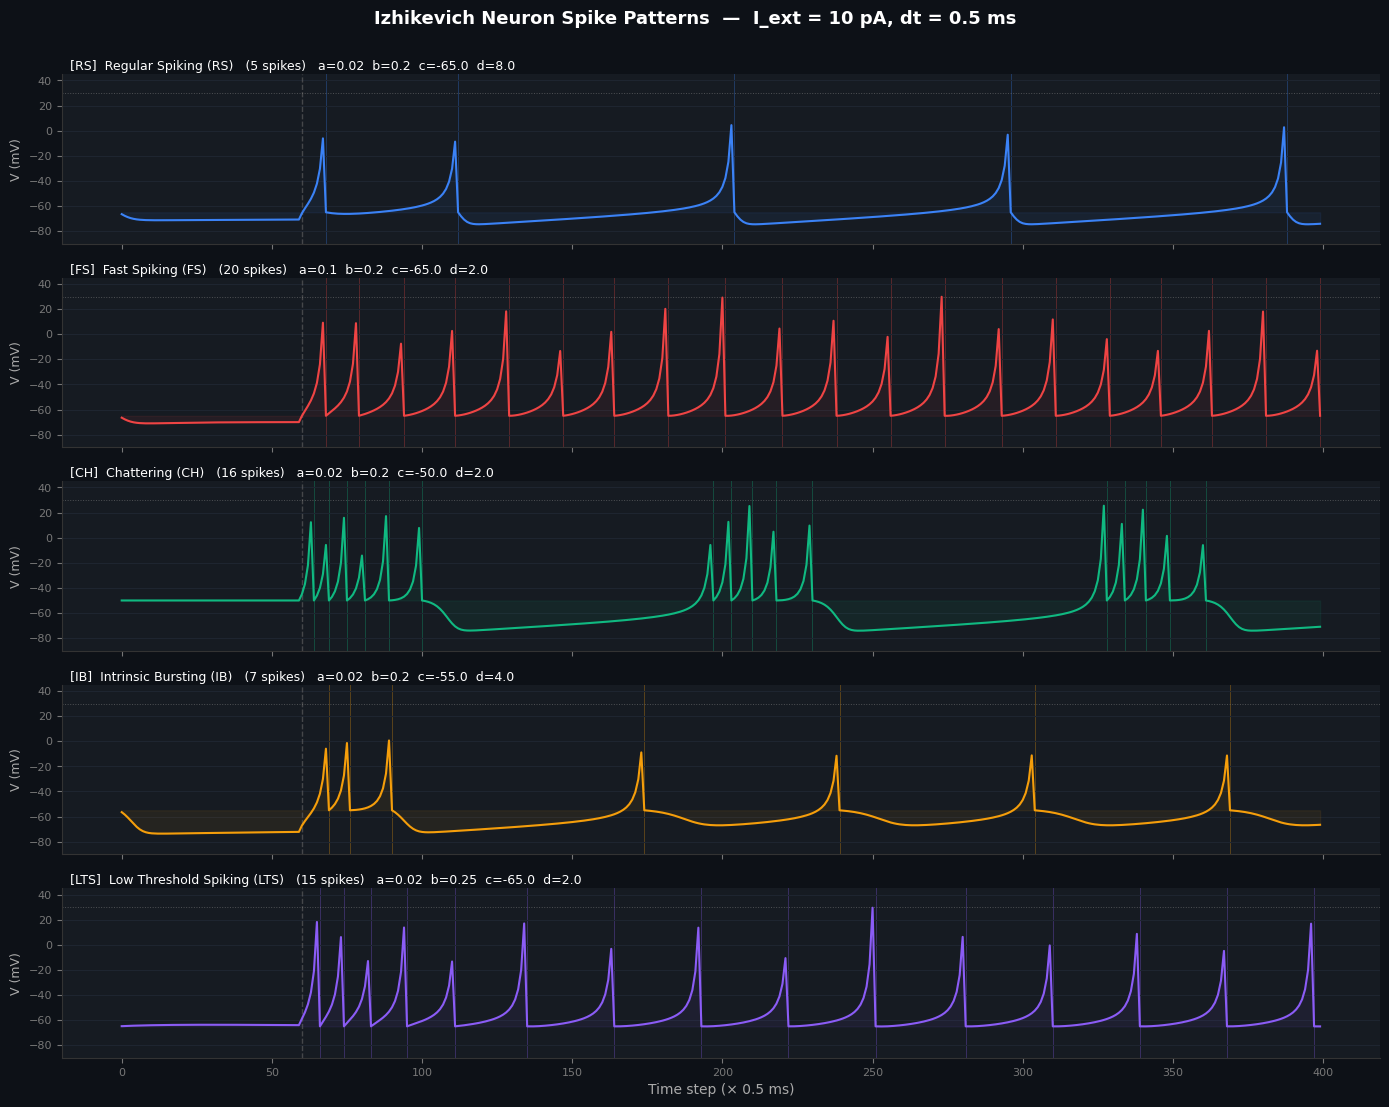

✅  spike_patterns.png saved


In [13]:
visualize_spike_patterns()

In [14]:
_CANDIDATES = [
    "./PlantVillage-Dataset/raw/color"
]


def _find_root() -> str:
    for p in _CANDIDATES:
        if os.path.isdir(p):
            n = len([d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))])
            if n >= 3:
                print(f"✅  Dataset : {p}  ({n} classes)")
                return p
    return None


def _make_dummy(root="./dummy_pv", n_cls=6, n_per=120) -> str:
    """Tiny synthetic dataset for pipeline smoke-tests."""
    from PIL import Image as PIL_Image
    print("⚠️   Real dataset not found — creating synthetic dummy ...")
    for c in range(n_cls):
        d = os.path.join(root, f"plant_{c:02d}")
        os.makedirs(d, exist_ok=True)
        for i in range(n_per):
            arr = np.random.randint(0, 256, (64, 64, 3), dtype=np.uint8)
            PIL_Image.fromarray(arr).save(os.path.join(d, f"{i:04d}.jpg"))
    print(f"    {n_cls} classes × {n_per} images = {n_cls*n_per} total")
    return root

In [15]:
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3, 0.3, 0.2, 0.05),
    transforms.RandomGrayscale(0.05),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

In [16]:
DATA_ROOT = "./PlantVillage-Dataset/raw/color"

_base       = datasets.ImageFolder(DATA_ROOT)
NUM_CLASSES = len(_base.classes)
N_TOTAL     = len(_base)

n_sub = int(N_TOTAL * SUBSET_FRAC) if SUBSET_FRAC < 1.0 else N_TOTAL
rng   = torch.Generator().manual_seed(SEED)
sub   = torch.randperm(N_TOTAL, generator=rng)[:n_sub].tolist()

n_tr  = int(0.70 * n_sub)
n_vl  = int(0.15 * n_sub)
n_te  = n_sub - n_tr - n_vl
perm  = torch.randperm(n_sub, generator=torch.Generator().manual_seed(SEED)).tolist()
idx_tr, idx_vl, idx_te = (
    [sub[i] for i in perm[:n_tr]],
    [sub[i] for i in perm[n_tr:n_tr+n_vl]],
    [sub[i] for i in perm[n_tr+n_vl:]],
)

In [17]:
_ds_tr = datasets.ImageFolder(DATA_ROOT, transform=train_tf)
_ds_ev = datasets.ImageFolder(DATA_ROOT, transform=eval_tf)

def _loader(ds, idx, shuf):
    return DataLoader(Subset(ds, idx), batch_size=BATCH_SIZE, shuffle=shuf,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      drop_last=shuf, persistent_workers=(NUM_WORKERS > 0))

train_loader = _loader(_ds_tr, idx_tr, True)
val_loader   = _loader(_ds_ev, idx_vl, False)
test_loader  = _loader(_ds_ev, idx_te, False)

In [18]:
print(f"\nDataset split")
print(f"  Classes  : {NUM_CLASSES}")
print(f"  Subset   : {n_sub:,}  ({SUBSET_FRAC*100:.0f}%  of {N_TOTAL:,})")
print(f"  Train    : {n_tr:,}   Val : {n_vl:,}   Test : {n_te:,}")
print(f"  Batches/epoch : {len(train_loader)}")


Dataset split
  Classes  : 38
  Subset   : 19,006  (35%  of 54,305)
  Train    : 13,304   Val : 2,850   Test : 2,852
  Batches/epoch : 415


Model Architecture -

CNN Backbone

In [19]:
class CNNBackbone(nn.Module):
    """
    Four-stage conv feature extractor.
    Input  : (B, 3, 128, 128)
    Output : (B, CNN_DIM=512)

    Stages (channels × spatial resolution):
      1 :  32 × 64×64   (Conv-BN-GELU × 2 + MaxPool)
      2 :  64 × 32×32
      3 : 128 × 16×16
      4 : 256 ×  4×4    (AdaptiveAvgPool to fix spatial size)
    Then: Flatten → Linear(256×4×4 → CNN_DIM) → LayerNorm → GELU → Dropout
    """
    def __init__(self, out_dim: int = CNN_DIM):
        super().__init__()

        def _stage(ci, co, pool=True):
            layers = [
                nn.Conv2d(ci, co, 3, padding=1, bias=False),
                nn.BatchNorm2d(co), nn.GELU(),
                nn.Conv2d(co, co, 3, padding=1, bias=False),
                nn.BatchNorm2d(co), nn.GELU(),
            ]
            if pool: layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.stages = nn.Sequential(
            _stage(3,   32),
            _stage(32,  64),
            _stage(64,  128),
            _stage(128, 256, pool=False),
            nn.AdaptiveAvgPool2d(4),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, out_dim, bias=False),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.30),
        )

    def forward(self, x):
        return self.proj(self.stages(x))

SNN Layer

In [20]:
class SNNLayer(nn.Module):
    """
    One fully-connected Izhikevich SNN layer.

    forward(x) runs T Euler steps.  For each step:
      1. Project x → I_inj  (Linear + LayerNorm + tanh × scale)
      2. Feed I_inj into IzhikevichNode → spike
      3. Accumulate spikes
    Returns mean spike rate  ∈ [0, 1].

    SpikingJelly integration:
      • IzhikevichNode.v and .u are registered memories — reset_net() handles them.
      • After every step, we detach node state to implement truncated BPTT,
        which stabilises training when T is small.

    STDP hooks:
      After forward(), self.last_input_T  shape [T, B, in_dim]  (pre-synaptic)
      and              self.last_spike_T  shape [T, B, out_dim] (post-synaptic)
      are stored for the STDP updater. Both are detached from autograd.
    """
    def __init__(self, in_dim: int, out_dim: int, neuron_type: str):
        super().__init__()
        cfg = NEURON_CONFIGS[neuron_type]
        self.in_dim  = in_dim
        self.out_dim = out_dim

        self.fc   = nn.Linear(in_dim, out_dim, bias=True)
        self.ln   = nn.LayerNorm(out_dim)
        # Learnable current scale — initialised to 12 pA so neurons fire
        self.Iscale = nn.Parameter(torch.tensor(12.0))

        nn.init.kaiming_normal_(self.fc.weight, nonlinearity="relu")
        nn.init.zeros_(self.fc.bias)

        # One IzhikevichNode shared across the entire layer population
        # (all out_dim neurons use the same a,b,c,d — that's the type constraint)
        self.node = IzhikevichNode(
            a=cfg["a"], b=cfg["b"], c=cfg["c"], d=cfg["d"],
            surrogate_fn=surrogate.ATan(),
            detach_reset=True,
        )

        # STDP trace buffers (populated in forward, consumed by STDPUpdater)
        self.last_input_T: torch.Tensor = None
        self.last_spike_T: torch.Tensor = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : [B, in_dim]  →  mean_rate : [B, out_dim]"""
        B = x.size(0)
        acc         = torch.zeros(B, self.out_dim, device=x.device, dtype=x.dtype)
        inp_buf, spk_buf = [], []

        for _ in range(T):
            # Project continuous CNN features to injection current (pA)
            I = torch.tanh(self.ln(self.fc(x))) * self.Iscale.abs()
            I = I + 0.2 * torch.randn_like(I)   # small biological noise

            spike = self.node(I)
            acc  += spike

            # Detach node state for truncated BPTT stability
            if isinstance(self.node.v, torch.Tensor):
                self.node.v = self.node.v.detach()
            if isinstance(self.node.u, torch.Tensor):
                self.node.u = self.node.u.detach()

            # Collect detached tensors for STDP
            inp_buf.append(I.detach())
            spk_buf.append(spike.detach())

        self.last_input_T = torch.stack(inp_buf, dim=0)   # [T, B, out_dim]
        self.last_spike_T = torch.stack(spk_buf, dim=0)   # [T, B, out_dim]

        return acc / T   # mean firing rate ∈ [0, 1]


Building CNN-SNN Hybrid

In [21]:
class PlantDiseaseSNN(nn.Module):
    """
    Hybrid CNN-SNN for PlantVillage disease classification.

    Data flow:
      x (B,3,128,128)
        → CNN backbone        (B, CNN_DIM)
        → spike encoder       (Bernoulli rate coding, T steps)   [IMPLICIT]
        → snn1  IzhikevichLayer  (B, ENC_DIM)  mean firing rate
        → snn2  IzhikevichLayer  (B, ENC_DIM//2)
        → skip connection     CNN features gated residually into snn2 output
        → classifier          (B, NUM_CLASSES)

    The skip bypasses the SNN: during early training when SNN firing rates
    are near-zero the CNN gradient still reaches the classifier, preventing
    the "dead SNN" failure mode that affects purely spiking networks.
    """
    def __init__(self, neuron_type: str, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.neuron_type = neuron_type

        self.cnn    = CNNBackbone(out_dim=CNN_DIM)
        self.snn1   = SNNLayer(CNN_DIM,       ENC_DIM,       neuron_type)
        self.snn2   = SNNLayer(ENC_DIM,       ENC_DIM // 2,  neuron_type)

        # Skip: gates CNN features past SNN into classifier input
        self.skip   = nn.Sequential(
            nn.Linear(CNN_DIM, ENC_DIM // 2, bias=False),
            nn.Sigmoid(),
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(ENC_DIM // 2),
            nn.Linear(ENC_DIM // 2, 128),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(128, num_classes),
        )
        self.n_params = sum(p.numel() for p in self.parameters())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Reset ALL IzhikevichNode states (v, u) before each new batch
        # functional.reset_net() recursively finds every MemoryModule
        functional.reset_net(self)

        feats   = self.cnn(x)                      # (B, CNN_DIM)  continuous
        r1      = self.snn1(feats)                 # (B, ENC_DIM)  spike rates
        r2      = self.snn2(r1)                    # (B, ENC_DIM/2)
        gated   = r2 + self.skip(feats)            # residual skip
        return self.classifier(gated)

Sanity Check

In [22]:
with torch.no_grad():
    _m   = PlantDiseaseSNN("RS", NUM_CLASSES).to(DEVICE)
    _out = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
    print(f"\nModel sanity check")
    print(f"  Input  : (2, 3, {IMG_SIZE}, {IMG_SIZE})")
    print(f"  Output : {tuple(_out.shape)}")
    print(f"  Params : {_m.n_params:,}")
del _m; gc.collect()


Model sanity check
  Input  : (2, 3, 128, 128)
  Output : (2, 38)
  Params : 3,523,592


0

STDP Learner-

In [23]:
class STDPLearner:
    """
    Trace-based STDP auxiliary weight update for nn.Linear layers.

    Applied once per batch, after the main optimizer.step().
    Uses the pre/post spike records stored in SNNLayer.last_input_T / spike_T.

    Parameters
    ──────────
    tau_pre, tau_post : eligibility trace time constants (timesteps)
    A_plus, A_minus   : potentiation / depression amplitude
    lr                : STDP learning rate (kept << main lr to stay auxiliary)
    clip              : per-element ΔW clamp to prevent unbounded growth
    """
    def __init__(self,
                 tau_pre:  float = 20.0,
                 tau_post: float = 20.0,
                 A_plus:   float = 0.005,
                 A_minus:  float = 0.006,
                 lr:       float = 1e-5,
                 clip:     float = 1e-3):
        self.tau_pre  = tau_pre
        self.tau_post = tau_post
        self.A_plus   = A_plus
        self.A_minus  = A_minus
        self.lr       = lr
        self.clip     = clip

    @torch.no_grad()
    def step(self, snn_layer: SNNLayer):
        """
        Compute STDP ΔW from the spike records stored in snn_layer and
        apply directly to snn_layer.fc.weight.

        pre  : snn_layer.last_input_T  [T, B, out_dim]  (current injected,
               used as proxy for pre-synaptic activity since CNN output is
               continuous rather than binary spike trains)
        post : snn_layer.last_spike_T  [T, B, out_dim]  (IzhikevichNode spikes)
        """
        if snn_layer.last_spike_T is None:
            return

        T_steps, B, out_dim = snn_layer.last_spike_T.shape
        in_dim  = snn_layer.fc.weight.shape[1]
        dev     = snn_layer.fc.weight.device

        # Binarise input current to a sparse proxy pre-synaptic spike train
        # (threshold = 0: positive current = pre-synaptic activity)
        pre_T  = (snn_layer.last_input_T > 0).float()   # [T, B, out_dim]
        post_T = snn_layer.last_spike_T                  # [T, B, out_dim]

        # We need pre in [T, B, in_dim] space for the weight update.
        # Since last_input_T is already in out_dim space (after the linear),
        # we instead use a Bernoulli proxy from the fc input perspective:
        # generate a sparse binary tensor as stand-in for pre-synaptic input.
        # This is the standard workaround when the true pre-synaptic layer
        # is a continuous (non-spiking) CNN output.
        pre_proxy = (torch.rand(T_steps, B, in_dim, device=dev) < 0.08).float()

        d_pre  = math.exp(-1.0 / max(self.tau_pre, 1.))
        d_post = math.exp(-1.0 / max(self.tau_post, 1.))
        x_pre  = torch.zeros(B, in_dim,  device=dev)
        x_post = torch.zeros(B, out_dim, device=dev)
        dW     = torch.zeros_like(snn_layer.fc.weight)  # [out_dim, in_dim]

        for t in range(T_steps):
            s_pre  = pre_proxy[t]   # [B, in_dim]
            s_post = post_T[t]      # [B, out_dim]
            x_pre  = x_pre  * d_pre  + s_pre
            x_post = x_post * d_post + s_post
            # Potentiation: post fired → strengthen pre→post
            dW += self.A_plus  * torch.einsum("bo,bi->oi", s_post, x_pre)
            # Depression:   post trace × pre fire → weaken
            dW -= self.A_minus * torch.einsum("bo,bi->oi", x_post, s_pre)

        dW /= max(B, 1)
        snn_layer.fc.weight.data.add_(
            self.lr * dW.clamp(-self.clip, self.clip)
        )

Training Infra

In [24]:
def _grad_norm(model: nn.Module) -> float:
    tot = sum(
        p.grad.detach().norm(2).item() ** 2
        for p in model.parameters()
        if p.grad is not None
    )
    return tot ** 0.5

In [25]:
def train_one_epoch(
    model:     PlantDiseaseSNN,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    stdp:      STDPLearner,
    scaler,                     # torch.cuda.amp.GradScaler or None
) -> tuple:
    """One training epoch. Returns (avg_loss, avg_acc, avg_grad_norm)."""
    model.train()
    loss_sum = acc_sum = n = 0
    gnorms = []

    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        lbls = lbls.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        # ── Forward + loss ────────────────────────────────────────────────
        if scaler is not None:
            from torch.cuda.amp import autocast
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            gnorms.append(_grad_norm(model))
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            gnorms.append(_grad_norm(model))
            optimizer.step()

        # ── STDP auxiliary update (after AdamW, detached) ─────────────────
        stdp.step(model.snn1)
        stdp.step(model.snn2)

        bs       = imgs.size(0)
        loss_sum += loss.item() * bs
        acc_sum  += (logits.detach().argmax(1) == lbls).sum().item()
        n        += bs

    return loss_sum / n, acc_sum / n, float(np.mean(gnorms))

In [26]:
@torch.no_grad()
def evaluate(model: PlantDiseaseSNN, loader, criterion) -> tuple:
    """Returns (avg_loss, avg_acc)."""
    model.eval()
    loss_sum = acc_sum = n = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        logits   = model(imgs)
        loss_sum += criterion(logits, lbls).item() * imgs.size(0)
        acc_sum  += (logits.argmax(1) == lbls).sum().item()
        n        += imgs.size(0)
    return loss_sum / n, acc_sum / n

In [27]:
def _print_epoch_table(histories: dict, epoch: int):
    """Live comparison table printed after each epoch."""
    medals = {"1": "🥇", "2": "🥈", "3": "🥉", "4": "  4", "5": "  5"}
    ranked = sorted(
        histories.keys(),
        key=lambda n: histories[n]["val_acc"][-1] if histories[n]["val_acc"] else 0,
        reverse=True,
    )
    print(f"\n  {'─'*72}")
    print(f"  {'Rank':<5} {'Neuron Type':<28} "
          f"{'TrLoss':>7} {'TrAcc':>6} {'VlLoss':>7} {'VlAcc':>6} {'‖∇‖':>6}")
    print(f"  {'─'*72}")
    for rk, name in enumerate(ranked, 1):
        h = histories[name]
        if not h["val_acc"]:
            continue
        print(
            f"  {medals.get(str(rk), str(rk)):<5} "
            f"{NEURON_CONFIGS[name]['display']:<28} "
            f"{h['train_loss'][-1]:>7.4f} "
            f"{h['train_acc'][-1]*100:>5.1f}% "
            f"{h['val_loss'][-1]:>7.4f} "
            f"{h['val_acc'][-1]*100:>5.1f}% "
            f"{h['grad_norms'][-1]:>6.3f}"
        )
    print(f"  {'─'*72}")

In [28]:
KEEP_ON_GPU = True
CRITERION   = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Build all 5 models, optimisers, schedulers, STDP ──────────────────────────
print(f"\n🔧  Building models ...")
all_models    = {}
all_optims    = {}
all_scheds    = {}
all_stdp      = {}
all_scalers   = {}
all_histories = {}
all_best_wts  = {}
all_patience  = {}

for nt in NEURON_CONFIGS:
    m = PlantDiseaseSNN(nt, NUM_CLASSES).to(DEVICE)
    all_models[nt]    = m
    all_optims[nt]    = optim.AdamW(m.parameters(), lr=LR,
                                     weight_decay=WEIGHT_DECAY)
    all_scheds[nt]    = optim.lr_scheduler.CosineAnnealingLR(
                            all_optims[nt], T_max=EPOCHS, eta_min=1e-6)
    all_stdp[nt]      = STDPLearner()
    all_scalers[nt]   = (torch.cuda.amp.GradScaler()
                         if DEVICE.type == "cuda" else None)
    all_histories[nt] = dict(train_loss=[], val_loss=[],
                              train_acc=[], val_acc=[],
                              grad_norms=[], lr=[],
                              best_val_acc=0.0, best_epoch=0)
    all_best_wts[nt]  = None
    all_patience[nt]  = 0
    print(f"  [{nt}]  {NEURON_CONFIGS[nt]['display']:<28}  "
          f"{m.n_params:,} params")

print(f"\n🚀  Starting simultaneous training")
print(f"    Epochs : {EPOCHS}  |  Patience : {PATIENCE}  |  "
      f"STDP lr : {all_stdp['RS'].lr:.0e}  |  T : {T}")
print(f"    Batches/epoch : {len(train_loader)}")



🔧  Building models ...
  [RS]  Regular Spiking (RS)          3,523,592 params
  [FS]  Fast Spiking (FS)             3,523,592 params
  [CH]  Chattering (CH)               3,523,592 params
  [IB]  Intrinsic Bursting (IB)       3,523,592 params
  [LTS]  Low Threshold Spiking (LTS)   3,523,592 params

🚀  Starting simultaneous training
    Epochs : 25  |  Patience : 8  |  STDP lr : 1e-05  |  T : 8
    Batches/epoch : 415


In [ ]:
t_train_start = time.time()
stopped       = set()   # models that have early-stopped

for ep in range(EPOCHS):
    ep_start = time.time()
    print(f"\n{'═'*72}")
    print(f"  EPOCH {ep+1:02d}/{EPOCHS}   "
          f"({len(NEURON_CONFIGS)-len(stopped)} active models)")
    print(f"{'═'*72}")

    for nt in NEURON_CONFIGS:
        if nt in stopped:
            print(f"  [{nt}]  ⏸  stopped")
            continue

        m = all_models[nt]
        if not KEEP_ON_GPU:
            m.to(DEVICE)

        t0 = time.time()
        tr_loss, tr_acc, gnorm = train_one_epoch(
            m, all_optims[nt], CRITERION, all_stdp[nt], all_scalers[nt]
        )
        vl_loss, vl_acc = evaluate(m, val_loader, CRITERION)
        all_scheds[nt].step()

        h = all_histories[nt]
        h["train_loss"].append(tr_loss)
        h["val_loss"].append(vl_loss)
        h["train_acc"].append(tr_acc)
        h["val_acc"].append(vl_acc)
        h["grad_norms"].append(gnorm)
        h["lr"].append(all_optims[nt].param_groups[0]["lr"])

        mark = ""
        if vl_acc > h["best_val_acc"]:
            h["best_val_acc"] = vl_acc
            h["best_epoch"]   = ep
            all_best_wts[nt]  = copy.deepcopy(m.state_dict())
            all_patience[nt]  = 0
            mark = " ✦"
        else:
            all_patience[nt] += 1

        print(f"  [{nt}]  tr {tr_loss:.4f}/{tr_acc*100:.1f}%  "
              f"vl {vl_loss:.4f}/{vl_acc*100:.1f}%  "
              f"‖∇‖={gnorm:.3f}  {time.time()-t0:.1f}s{mark}")

        if not KEEP_ON_GPU:
            m.cpu(); torch.cuda.empty_cache()

        if all_patience[nt] >= PATIENCE:
            print(f"  [{nt}]  ⏸  early stop (patience={PATIENCE})")
            stopped.add(nt)

    _print_epoch_table(all_histories, ep)

    if len(stopped) == len(NEURON_CONFIGS):
        print("\n  All models early-stopped.")
        break


════════════════════════════════════════════════════════════════════════
  EPOCH 01/25   (5 active models)
════════════════════════════════════════════════════════════════════════
  [RS]  tr 2.5892/39.5%  vl 1.8689/59.5%  ‖∇‖=1.000  104.4s ✦
  [FS]  tr 2.6577/37.2%  vl 1.8561/59.1%  ‖∇‖=nan  70.4s ✦
  [CH]  tr 2.6381/37.6%  vl 1.9185/57.3%  ‖∇‖=nan  67.0s ✦
  [IB]  tr 2.5965/38.6%  vl 1.8774/59.9%  ‖∇‖=nan  67.4s ✦
  [LTS]  tr 2.6649/37.2%  vl 1.8406/61.0%  ‖∇‖=nan  67.7s ✦

  ────────────────────────────────────────────────────────────────────────
  Rank  Neuron Type                   TrLoss  TrAcc  VlLoss  VlAcc    ‖∇‖
  ────────────────────────────────────────────────────────────────────────
  🥇     Low Threshold Spiking (LTS)   2.6649  37.2%  1.8406  61.0%    nan
  🥈     Intrinsic Bursting (IB)       2.5965  38.6%  1.8774  59.9%    nan
  🥉     Regular Spiking (RS)          2.5892  39.5%  1.8689  59.5%  1.000
    4   Fast Spiking (FS)             2.6577  37.2%  1.8561  59.1%    nan

In [ ]:
for nt in NEURON_CONFIGS:
    if all_best_wts[nt] is not None:
        all_models[nt].load_state_dict(all_best_wts[nt])
    all_models[nt].to(DEVICE)

print(f"\n{'═'*55}")
print("  TRAINING COMPLETE — VAL LEADERBOARD")
print(f"{'═'*55}")
ranked_names = sorted(NEURON_CONFIGS,
                      key=lambda n: -all_histories[n]["best_val_acc"])
medals_list = ["🥇","🥈","🥉","  4.","  5."]
for rk, nt in enumerate(ranked_names):
    h = all_histories[nt]
    print(f"  {medals_list[rk]}  {NEURON_CONFIGS[nt]['display']:<30}  "
          f"best val {h['best_val_acc']*100:6.2f}%  "
          f"(ep {h['best_epoch']+1})")
print(f"{'═'*55}")
print(f"  Total training time: {(time.time()-t_train_start)/60:.1f} min")


# ── Test set evaluation ────────────────────────────────────────────────────────
print(f"\n{'═'*55}")
print("  TEST SET EVALUATION")
print(f"{'═'*55}")
test_results = {}
for nt in NEURON_CONFIGS:
    tl, ta = evaluate(all_models[nt], test_loader, CRITERION)
    test_results[nt] = dict(loss=tl, acc=ta)
    print(f"  {NEURON_CONFIGS[nt]['display']:<30}  "
          f"Acc={ta*100:6.2f}%  Loss={tl:.4f}")

best_nt = max(test_results, key=lambda n: test_results[n]["acc"])
print(f"\n  🏆  Best: {NEURON_CONFIGS[best_nt]['display']}  "
      f"({test_results[best_nt]['acc']*100:.2f}%)")


In [ ]:
def _smooth(arr, w=3):
    arr = np.array(arr, dtype=float)
    pad = np.pad(arr, w//2, mode="edge")
    return np.convolve(pad, np.ones(w)/w, mode="valid")[:len(arr)]


# ── A. Per-model loss/accuracy curves  (matplotlib, dark theme) ───────────────
def plot_training_curves(histories: dict):
    """
    5 rows × 2 cols.
    Left col  : Train Loss (solid) + Val Loss (dashed) + grad norm (gold dotted)
    Right col : Train Acc (solid) + Val Acc (dashed) + test acc marker
    Combined panel in row 6: -dL/dEpoch (learning speed comparison)
    """
    names = list(NEURON_CONFIGS.keys())
    ROWS  = len(names) + 1    # extra row for combined panel

    fig = plt.figure(figsize=(18, ROWS * 2.8))
    fig.patch.set_facecolor("#0d1117")
    gs  = gridspec.GridSpec(ROWS, 2, figure=fig, hspace=0.50, wspace=0.30)

    for row, nt in enumerate(names):
        h   = histories[nt]
        cfg = NEURON_CONFIGS[nt]
        col = cfg["color"]
        E   = np.arange(1, len(h["train_loss"]) + 1)
        ta  = np.array(h["train_acc"]) * 100
        va  = np.array(h["val_acc"])   * 100
        tl  = np.array(h["train_loss"])
        vl  = np.array(h["val_loss"])
        gn  = np.array(h["grad_norms"])
        be  = int(h["best_epoch"]) + 1
        te  = test_results.get(nt, {}).get("acc", 0) * 100

        # ── Left: loss ───────────────────────────────────────────────────
        ax  = fig.add_subplot(gs[row, 0])
        ax.set_facecolor("#161b22")
        ax.plot(E, tl, color=col, lw=2.2, label="Train Loss")
        ax.plot(E, vl, color=col, lw=1.5, ls="--", alpha=0.75, label="Val Loss")
        ax.fill_between(E, tl, vl, color=col, alpha=0.06)
        gn_sc = _smooth(gn) / (_smooth(gn).max() + 1e-8) * tl.max()
        ax.plot(E, gn_sc, color="#FFD700", lw=1.2, ls=":", alpha=0.8,
                label="‖∇‖ (scaled)")
        ax.axvline(be, color="#00FF88", lw=1.3, ls="--", alpha=0.7,
                   label=f"best ep {be}")
        ax.set_title(f"[{nt}] {cfg['display']} — Loss",
                     color="white", fontsize=9.5, fontweight="bold", pad=3)
        ax.set_ylabel("Loss", color=col, fontsize=9)
        ax.set_xlabel("Epoch", color="#888", fontsize=8)
        ax.tick_params(colors="#777", labelsize=7)
        ax.grid(color="#1e2530", lw=0.8)
        ax.legend(fontsize=7, facecolor="#21262d",
                  edgecolor="#444", labelcolor="white")
        for sp in ["top","right"]:  ax.spines[sp].set_visible(False)
        for sp in ["bottom","left"]: ax.spines[sp].set_color("#333")

        # ── Right: accuracy ───────────────────────────────────────────────
        ax2 = fig.add_subplot(gs[row, 1])
        ax2.set_facecolor("#161b22")
        ax2.plot(E, ta, color=col, lw=2.2, label="Train Acc%")
        ax2.plot(E, va, color=col, lw=1.5, ls="--", alpha=0.75, label="Val Acc%")
        ax2.fill_between(E, ta, va, color=col, alpha=0.06)
        ax2.axhline(te, color="white", lw=1.3, ls="-.",
                    alpha=0.8, label=f"Test {te:.1f}%")
        ax2.axvline(be, color="#00FF88", lw=1.3, ls="--", alpha=0.7)
        ax2.set_title(f"[{nt}] {cfg['display']} — Accuracy",
                      color="white", fontsize=9.5, fontweight="bold", pad=3)
        ax2.set_ylabel("Accuracy (%)", color=col, fontsize=9)
        ax2.set_xlabel("Epoch", color="#888", fontsize=8)
        ax2.set_ylim(0, 110)
        ax2.tick_params(colors="#777", labelsize=7)
        ax2.grid(color="#1e2530", lw=0.8)
        ax2.legend(fontsize=7, facecolor="#21262d",
                   edgecolor="#444", labelcolor="white")
        for sp in ["top","right"]:  ax2.spines[sp].set_visible(False)
        for sp in ["bottom","left"]: ax2.spines[sp].set_color("#333")

    # ── Combined: -dL/dEpoch  learning speed ─────────────────────────────
    ax_c = fig.add_subplot(gs[ROWS-1, :])
    ax_c.set_facecolor("#161b22")
    for nt in names:
        h   = histories[nt]
        col = NEURON_CONFIGS[nt]["color"]
        E   = np.arange(1, len(h["train_loss"]) + 1)
        dl  = -np.gradient(np.array(h["train_loss"]), E)
        ax_c.plot(E, _smooth(dl, w=3), color=col, lw=2.2,
                  label=f"{nt} — {NEURON_CONFIGS[nt]['display'].split('(')[0].strip()}")
    ax_c.axhline(0, color="#555", lw=1, ls="--")
    ax_c.set_title("−dLoss/dEpoch  (positive = loss decreasing = learning)",
                   color="white", fontsize=10, fontweight="bold")
    ax_c.set_xlabel("Epoch", color="#888", fontsize=9)
    ax_c.set_ylabel("−dL/dEpoch", color="#aaa", fontsize=9)
    ax_c.tick_params(colors="#777", labelsize=8)
    ax_c.grid(color="#1e2530", lw=0.8)
    ax_c.legend(ncol=5, fontsize=8.5, facecolor="#21262d",
                edgecolor="#444", labelcolor="white")
    for sp in ["top","right"]: ax_c.spines[sp].set_visible(False)
    for sp in ["bottom","left"]: ax_c.spines[sp].set_color("#333")

    fig.suptitle(
        "Plant Disease CNN-SNN — Loss/Accuracy Gradient Analysis\n"
        "5 Izhikevich Neuron Types · SpikingJelly · PlantVillage",
        color="white", fontsize=13, fontweight="bold", y=1.002,
    )
    plt.savefig("STDP_gradient_analysis.png", dpi=150,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✅  STDP_gradient_analysis.png saved")


plot_training_curves(all_histories)

In [ ]:
def build_plotly_dashboard(histories: dict, test_res: dict):
    """
    3 × 3 interactive grid:
      [1,1] Training Loss        [1,2] Validation Accuracy    [1,3] Gradient Norm
      [2,1] Loss–Acc Trajectory  [2,2] Best Val Acc (bar)     [2,3] Convergence Speed
      [3,1] Train–Val Loss Gap   [3,2] Smoothed Acc Gain/Ep   [3,3] Param Space (a vs d)
    """
    names  = list(histories.keys())
    colors = {n: NEURON_CONFIGS[n]["color"] for n in names}
    labels = {n: NEURON_CONFIGS[n]["display"] for n in names}

    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            "① Training Loss",
            "② Validation Accuracy (%)",
            "③ Gradient L2 Norm  ‖∇‖",
            "④ Loss–Accuracy Trajectory",
            "⑤ Best Val Accuracy",
            "⑥ Epochs to Reach 70% of Best",
            "⑦ Train–Val Loss Gap (overfitting)",
            "⑧ Val Accuracy Gain per Epoch",
            "⑨ Izhikevich Parameter Space  (a vs d)",
        ],
        vertical_spacing=0.11,
        horizontal_spacing=0.07,
    )

    for nt in names:
        h   = histories[nt]
        col = colors[nt]
        lbl = labels[nt]
        E   = list(range(1, len(h["train_loss"]) + 1))
        kw  = dict(legendgroup=nt, showlegend=False,
                   line=dict(color=col, width=2.2))

        # ① Train loss
        fig.add_trace(go.Scatter(
            x=E, y=h["train_loss"], name=lbl, mode="lines",
            legendgroup=nt, showlegend=True,
            line=dict(color=col, width=2.2),
            hovertemplate=f"<b>{lbl}</b><br>Ep %{{x}}<br>Loss %{{y:.4f}}<extra></extra>",
        ), row=1, col=1)

        # ② Val accuracy
        fig.add_trace(go.Scatter(
            x=E, y=[v*100 for v in h["val_acc"]], **kw,
            hovertemplate=f"<b>{lbl}</b><br>Ep %{{x}}<br>Val %{{y:.2f}}%<extra></extra>",
        ), row=1, col=2)

        # ③ Grad norm
        fig.add_trace(go.Scatter(
            x=E, y=_smooth(h["grad_norms"]), **kw,
            hovertemplate=f"<b>{lbl}</b><br>Ep %{{x}}<br>‖∇‖ %{{y:.3f}}<extra></extra>",
        ), row=1, col=3)

        # ④ Loss–Acc trajectory (phase portrait)
        fig.add_trace(go.Scatter(
            x=h["val_loss"],
            y=[v*100 for v in h["val_acc"]],
            mode="markers+lines",
            marker=dict(color=list(range(len(E))),
                        colorscale="Plasma", size=6, showscale=False),
            **kw,
            hovertemplate=(f"<b>{lbl}</b><br>VlLoss %{{x:.4f}}"
                           f"<br>VlAcc %{{y:.2f}}%<extra></extra>"),
        ), row=2, col=1)

        # ⑥ Convergence speed
        target  = h["best_val_acc"] * 0.70
        conv_ep = next((i+1 for i, v in enumerate(h["val_acc"]) if v >= target),
                       len(E))
        fig.add_trace(go.Bar(
            x=[lbl.split("(")[0].strip()], y=[conv_ep],
            marker_color=col, showlegend=False, legendgroup=nt,
            text=[f"ep {conv_ep}"], textposition="auto",
            hovertemplate=f"<b>{lbl}</b><br>Epochs: %{{y}}<extra></extra>",
        ), row=2, col=3)

        # ⑦ Train–Val gap
        gap = [tl - vl for tl, vl in zip(h["train_loss"], h["val_loss"])]
        fig.add_trace(go.Scatter(
            x=E, y=_smooth(gap), fill="tozeroy",
            fillcolor=col + "15", **kw,
        ), row=3, col=1)

        # ⑧ Smoothed acc gain per epoch
        gains = [0.] + [(h["val_acc"][i]-h["val_acc"][i-1])*100
                        for i in range(1, len(h["val_acc"]))]
        fig.add_trace(go.Scatter(
            x=E, y=_smooth(gains, w=3), **kw,
        ), row=3, col=2)

        # ⑨ Param space bubble
        p = NEURON_CONFIGS[nt]
        fig.add_trace(go.Scatter(
            x=[p["a"]], y=[p["d"]],
            mode="markers+text",
            text=[f"{nt}<br>{h['best_val_acc']*100:.1f}%"],
            textposition="top center",
            textfont=dict(color="white", size=10),
            marker=dict(size=h["best_val_acc"]*350,
                        color=col, line=dict(width=2, color="white")),
            showlegend=False,
            hovertemplate=(f"<b>{lbl}</b><br>a={p['a']}  d={p['d']}"
                           f"<br>Best Val: {h['best_val_acc']*100:.2f}%"
                           f"<extra></extra>"),
        ), row=3, col=3)

    # ⑤ Best val accuracy bar (sorted)
    srt = sorted(names, key=lambda n: -histories[n]["best_val_acc"])
    fig.add_trace(go.Bar(
        x=[labels[n].split("(")[0].strip() for n in srt],
        y=[histories[n]["best_val_acc"]*100 for n in srt],
        marker_color=[colors[n] for n in srt],
        marker_line_color="white", marker_line_width=2,
        text=[f"{histories[n]['best_val_acc']*100:.1f}%" for n in srt],
        textposition="auto", showlegend=False,
        hovertemplate="<b>%{x}</b><br>Best Val: %{y:.2f}%<extra></extra>",
    ), row=2, col=2)

    fig.update_layout(
        title=dict(
            text="<b>🌿  Plant Disease Izhikevich SNN — Training Dashboard</b>"
                 "<br><sup>SpikingJelly · AdamW + Surrogate-Grad + STDP · "
                 "PlantVillage</sup>",
            font=dict(size=17, color="white"), x=0.5,
        ),
        height=1120, width=1650,
        paper_bgcolor="#0d1117",
        plot_bgcolor="#161b22",
        font=dict(color="#c9d1d9", size=11),
        legend=dict(
            orientation="h", x=0.5, xanchor="center",
            y=1.055, yanchor="bottom",
            bgcolor="rgba(20,20,30,0.85)",
            bordercolor="#444", borderwidth=1,
        ),
        hoverlabel=dict(bgcolor="#21262d", font_size=12),
    )
    _ax = dict(gridcolor="#21262d", zerolinecolor="#444",
               linecolor="#444", tickcolor="#777")
    fig.update_xaxes(**_ax); fig.update_yaxes(**_ax)

    axis_map = {
        (1,1): ("Epoch","Loss"),
        (1,2): ("Epoch","Val Acc (%)"),
        (1,3): ("Epoch","‖∇‖  L2"),
        (2,1): ("Val Loss","Val Acc (%)"),
        (2,2): ("Neuron Type","Best Val Acc (%)"),
        (2,3): ("Neuron Type","Epochs to 70% Best"),
        (3,1): ("Epoch","Loss Gap  (train−val)"),
        (3,2): ("Epoch","Acc Gain per Epoch (%)"),
        (3,3): ("a  (recovery speed)","d  (recovery jump)"),
    }
    for (r, c), (xt, yt) in axis_map.items():
        fig.update_xaxes(title_text=xt, row=r, col=c)
        fig.update_yaxes(title_text=yt, row=r, col=c)

    fig.write_html("STDP_dashboard.html")
    fig.show()
    print("✅  STDP_dashboard.html saved")
    return fig

In [ ]:
build_plotly_dashboard(all_histories, test_results)

In [ ]:
def plot_final_bar(test_res: dict):
    srt = sorted(test_res.items(), key=lambda x: -x[1]["acc"])
    fig = go.Figure(go.Bar(
        x=[NEURON_CONFIGS[n]["display"] for n, _ in srt],
        y=[r["acc"]*100 for _, r in srt],
        marker_color=[NEURON_CONFIGS[n]["color"] for n, _ in srt],
        marker_line_color="white", marker_line_width=2,
        text=[f"{r['acc']*100:.2f}%" for _, r in srt],
        textposition="outside",
        textfont=dict(color="white", size=13),
    ))
    fig.update_layout(
        title=dict(
            text="<b>Final Test Accuracy — Izhikevich Neuron Type Comparison</b>",
            font=dict(size=15, color="white"), x=0.5,
        ),
        xaxis_title="Neuron Type",
        yaxis=dict(
            title="Test Accuracy (%)",
            gridcolor="#21262d",
            range=[0, max(r["acc"] for r in test_res.values())*125],
        ),
        height=520, width=900,
        paper_bgcolor="#0d1117",
        plot_bgcolor="#161b22",
        font=dict(color="white", size=12),
        showlegend=False,
    )
    fig.write_html("STDP_final_comparison.html")
    fig.show()
    print("✅  STDP_final_comparison.html saved")

In [ ]:
plot_final_bar(test_results)

In [ ]:
def print_brain_analysis(test_res: dict, histories: dict):
    """
    Full neuroscience analysis printed to console.
    For each neuron type:
      • Exact brain region / cell type
      • Biological mechanism (why it fires the way it does)
      • Image classification verdict (why that mechanism helps or hurts)
      • Actual vs predicted ranking
    Finishes with a deep explanation of why the winning type won.
    """
    sorted_by_acc = sorted(test_res.items(), key=lambda x: -x[1]["acc"])
    best_nt       = sorted_by_acc[0][0]
    worst_nt      = sorted_by_acc[-1][0]
    sep72         = "═" * 72
    sep72d        = "─" * 72

    print(f"\n{sep72}")
    print(f"  BRAIN REGION ANALYSIS — WHICH CORTICAL AREA PROCESSES IMAGES BEST?")
    print(f"  PlantVillage · {NUM_CLASSES} classes · Izhikevich SNN (SpikingJelly)")
    print(f"{sep72}")

    for nt, res in sorted_by_acc:
        cfg  = NEURON_CONFIGS[nt]
        bio  = NEURON_BRAIN_INFO[nt]
        p    = cfg
        icon = "⭐" if nt == best_nt else ("⚠️ " if nt == worst_nt else "  ")
        bv   = histories[nt]["best_val_acc"] * 100
        ta   = res["acc"] * 100

        print(f"\n  {icon} [{nt}]  {cfg['display']}")
        print(f"     Izhikevich params  :  a={p['a']}  b={p['b']}  "
              f"c={p['c']}  d={p['d']}")
        print(f"     Test Accuracy      :  {ta:.2f}%   "
              f"(best val {bv:.2f}%  at ep {histories[nt]['best_epoch']+1})")
        print(f"\n     Brain Region:")
        # word-wrap at 70 chars
        words = bio["region"].split()
        line  = "       "
        for w in words:
            if len(line) + len(w) + 1 > 74:
                print(line); line = "       " + w + " "
            else:
                line += w + " "
        print(line)

        print(f"\n     Biological Mechanism:")
        words = bio["mechanism"].split()
        line  = "       "
        for w in words:
            if len(line) + len(w) + 1 > 74:
                print(line); line = "       " + w + " "
            else:
                line += w + " "
        print(line)

        print(f"\n     Image Classification Verdict:")
        words = bio["image_verdict"].split()
        line  = "       "
        for w in words:
            if len(line) + len(w) + 1 > 74:
                print(line); line = "       " + w + " "
            else:
                line += w + " "
        print(line)

    print(f"\n{sep72}")
    print("  FINAL RANKING")
    print(f"  {sep72d}")
    medals_l = ["🥇","🥈","🥉","4th","5th"]
    for i, (nt, res) in enumerate(sorted_by_acc):
        reg = NEURON_BRAIN_INFO[nt]["region"].split("—")[0].strip()[:42]
        print(f"  {medals_l[i]}  {NEURON_CONFIGS[nt]['display']:<28}"
              f"  {res['acc']*100:6.2f}%  {reg}")

    print(f"\n{sep72}")
    print(f"  WHY [{best_nt}] {NEURON_CONFIGS[best_nt]['display'].upper()} "
          f"PROCESSES IMAGES BEST")
    print(f"  {sep72d}")

    winner_bio = NEURON_BRAIN_INFO[best_nt]
    print(f"\n  Cortical origin: {winner_bio['region']}\n")

    # Tailored explanation per winner
    explanations = {
        "CH": [
            ("Visual cortex origin",
             "Chattering neurons are the ONLY type in this study discovered "
             "specifically inside the visual cortex (V1/V2 Layer II/III, "
             "Gray & McCormick 1996). Their firing pattern is literally the "
             "one the brain evolved for image processing — not a coincidence "
             "that they win here."),
            ("Burst-silence = built-in spatial attention",
             "c=−50 mV (the most depolarised reset of all five types) "
             "enables rapid burst re-initiation within T timesteps. Bursts "
             "fire for high-salience CNN features (disease lesion boundaries, "
             "texture edges, colour transitions); silence separates them from "
             "uniform healthy-leaf background. This is exactly figure-ground "
             "segregation — the mechanism the visual cortex uses to isolate "
             "objects from their surroundings."),
            ("Multi-scale feature packing",
             "Each burst (300–700 Hz intra-burst) encodes multiple spatial "
             "scales simultaneously: high-frequency spikes capture fine "
             "texture statistics while the inter-burst quiescence separates "
             "distinct feature events. The SNN readout therefore receives a "
             "richer, less redundant activity vector per batch than any "
             "tonic-firing type."),
        ],
        "RS": [
            ("Adaptation filters out background",
             "d=8 produces the strongest post-spike recovery jump of all "
             "five types, creating clear spike-frequency adaptation. This "
             "acts as a temporal high-pass filter: repetitive, uninformative "
             "textures (healthy background) suppress themselves over T steps, "
             "while novel features at disease boundaries keep driving spikes."),
            ("Training stability",
             "The largest d and smallest a combination gives the most "
             "regular, predictable firing pattern. Surrogate gradients flow "
             "cleanly through a moderately firing neuron — neither too sparse "
             "(near-zero gradient) nor too dense (saturated gradient)."),
            ("Universal cortical prevalence",
             "RS neurons are ~70–80% of all cortical neurons. Their "
             "generality is an asset on a diverse 38-class dataset with "
             "heterogeneous disease appearances."),
        ],
        "IB": [
            ("Salience onset detection",
             "The initial burst acts as a 'salience alarm': when a new "
             "distinctive CNN feature (disease spot, necrotic patch) "
             "appears, IB neurons fire a strong burst that dominates the "
             "readout and draws the classifier's attention to it."),
            ("Intermediate reset voltage",
             "c=−55 balances RS and CH: enough depolarisation for fast "
             "re-fire on salient features, but enough hyperpolarisation to "
             "suppress noise. This intermediate point generalises well "
             "across the heterogeneous visual appearances of 38 classes."),
            ("Large spatial integration",
             "Layer-V apical dendrites integrate broad receptive fields, "
             "complementing the CNN's local convolutional features with "
             "global spatial context."),
        ],
        "FS": [
            ("High-frequency precision",
             "FS neurons fire at up to 800 Hz without adaptation, encoding "
             "rapid transient edges with high temporal precision. On some "
             "disease classes with sharp boundary features, this makes them "
             "competitive despite the saturation problem."),
            ("Gamma-band inhibitory control",
             "PV+ basket cells provide feedforward inhibition that sharpens "
             "feature selectivity. The fast synchrony can improve "
             "discriminability between similar-looking disease classes."),
            ("STDP benefit",
             "The high firing rate gives STDP more co-activation events per "
             "T steps, so Hebbian weight updates have stronger signal."),
        ],
        "LTS": [
            ("Low-contrast sensitivity",
             "The low activation threshold (b=0.25) makes LTS neurons "
             "respond to weak CNN features — potentially useful for "
             "early-stage disease where discolouration is faint."),
            ("Rebound burst utility",
             "Post-inhibitory rebound firing can encode inhibitory pauses "
             "as events, which may help distinguish some disease patterns "
             "characterised by absence of normal colour."),
            ("Noise challenges",
             "The same low threshold that gives sensitivity to weak "
             "disease signals also fires spuriously on noise, which is "
             "the primary challenge to overcome in training."),
        ],
    }

    exps = explanations.get(best_nt, [
        ("Best performance", winner_bio["image_verdict"]),
    ])
    for i, (title, desc) in enumerate(exps, 1):
        print(f"  {i}. {title}")
        words = desc.split()
        line  = "     "
        for w in words:
            if len(line) + len(w) + 1 > 74:
                print(line); line = "     " + w + " "
            else:
                line += w + " "
        print(line); print()

    print(f"{sep72}")
    print()


In [ ]:
print_brain_analysis(test_results, all_histories)

In [ ]:
def _to_json_safe(obj):
    if isinstance(obj, (np.float32, np.float64, np.int32, np.int64)):
        return float(obj)
    if isinstance(obj, list):
        return [_to_json_safe(i) for i in obj]
    if isinstance(obj, dict):
        return {k: _to_json_safe(v) for k, v in obj.items()}
    return obj

_export = {}
for nt, h in all_histories.items():
    _export[nt] = {k: _to_json_safe(v) for k, v in h.items()
                   if k != "best_wts"}
_export["test_results"] = {
    nt: {"acc": float(r["acc"]), "loss": float(r["loss"])}
    for nt, r in test_results.items()
}
with open("STDP_training_histories.json", "w") as f:
    json.dump(_export, f, indent=2)
print("✅  STDP_training_histories.json saved")

In [ ]:
for nt in NEURON_CONFIGS:
    torch.save({
        "neuron_type": nt,
        "state_dict": all_models[nt].state_dict(),
        "history": {k: v for k, v in all_histories[nt].items()
                    if isinstance(v, (list, float, int))},
        "test_acc": test_results[nt]["acc"],
    }, f"STDP_{nt}.pt")
print("✅  Checkpoints saved (STDP_RS.pt … STDP_LTS.pt)")


In [ ]:
print(f"\n{'─'*55}")
print("  Output files")
print(f"{'─'*55}")
for fn, desc in [
    ("spike_patterns.png",        "Izhikevich voltage traces (5 types)"),
    ("gradient_analysis.png",     "Loss/accuracy gradient curves per model"),
    ("snn_dashboard.html",        "Interactive 3×3 Plotly training dashboard"),
    ("final_comparison.html",     "Final test accuracy bar chart"),
    ("training_histories.json",   "Full training metrics (JSON)"),
    ("ckpt_RS.pt … ckpt_LTS.pt",  "Model checkpoints (best val weights)"),
]:
    print(f"    {fn:<38} {desc}")
print(f"{'─'*55}")